-------------**TEMEL AJANLAR - PİYASADA SADECE TEMEL AJANLAR VARSA**----------


*  pozitif haber duyarlılığı
*  negatif haber duyarlılığı
*  haber belleği
*  portföy büyüme performansları


Grafikte, temel ajanların portföy büyüme performansları; pozitif haber duyarlılığı $\theta^+$, negatif haber duyarlılığı $\theta^-$ ve haber belleği katsayısı $\gamma$ parametrelerine göre analiz edilmiştir.

### Açıklamalar:

#### 1. **Pozitif ve Negatif Duyarlılıklar ($\theta^+, \theta^-$)**

* $\theta^+ > \theta^-$ olduğunda ajanlar pozitif haberlerden daha fazla etkilenir; portföy değerleri genellikle yükselir.
* $\theta^- > \theta^+$ olduğunda, kötü haberlerin etkisi baskın olur; ortalama büyüme düşer.

#### 2. **Bellek Katsayısı ($\gamma$)**

* Küçük $\gamma$ değerleri (örneğin 0.1), haber etkilerinin hızla unutulduğunu gösterir → tepkiler daha dalgalı ama kısa ömürlüdür.
* Büyük $\gamma$ değerleri (örneğin 0.9), haberlerin etkisinin kalıcı olduğunu gösterir → etkiler daha süreklidir, ancak birikimsel risk oluşturur.






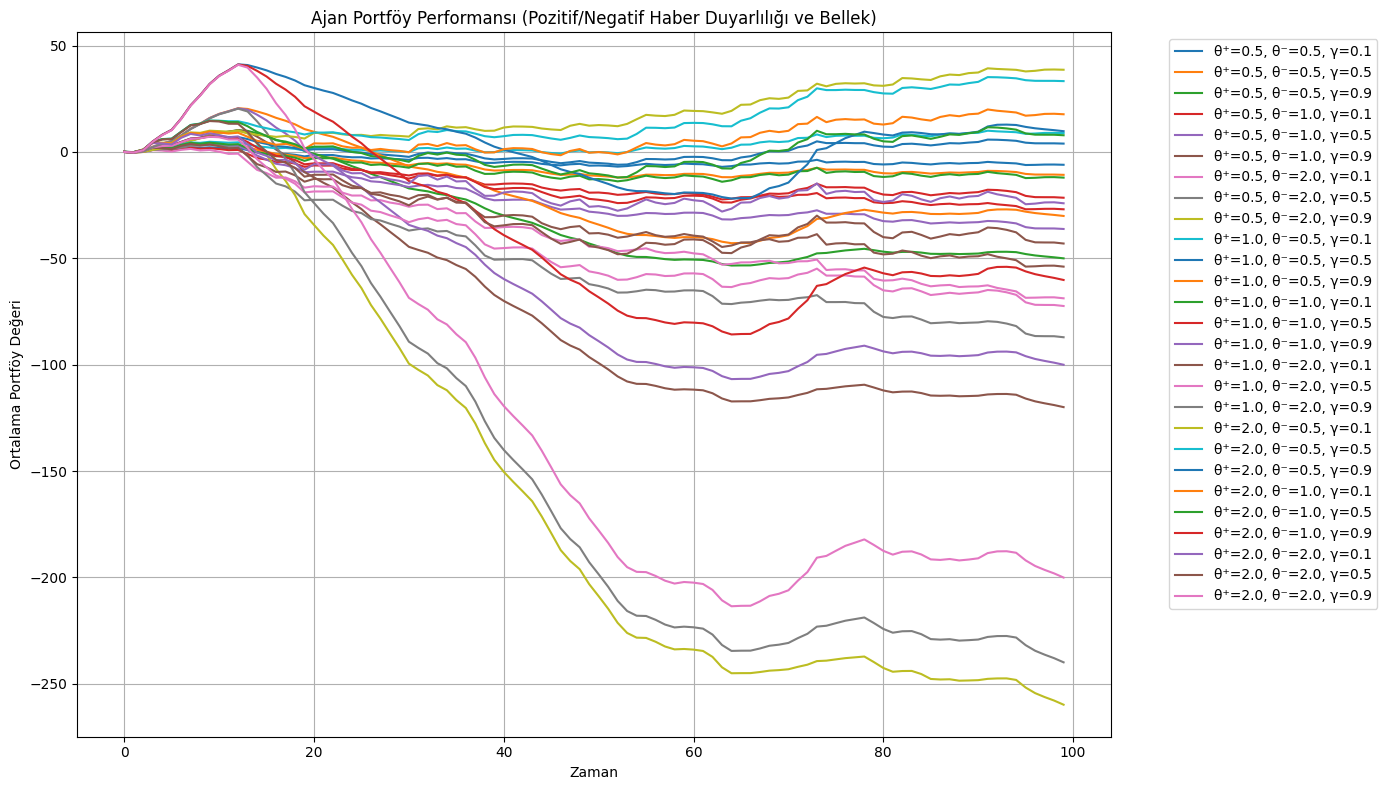

In [1]:
import numpy as np # NumPy kütüphanesini içe aktarıyoruz, sayısal hesaplamalar için kullanacağız.
import matplotlib.pyplot as plt # Matplotlib kütüphanesini içe aktarıyoruz, grafik çizmek için kullanacağız.

# Sabitler
np.random.seed(42) # Rastgele sayı üreteci için bir başlangıç değeri belirliyoruz, böylece sonuçlar tekrar üretilebilir olacak.
T = 100  # Zaman adım sayısını belirliyoruz, yani simülasyon 100 adım sürecek.
N = 50   # Ajan sayısını belirliyoruz, yani simülasyonda 50 ajan olacak.

# Parametre aralıkları
theta_pos_values = [0.5, 1.0, 2.0] # Pozitif haber duyarlılığı için olası değerleri belirliyoruz.
theta_neg_values = [0.5, 1.0, 2.0] # Negatif haber duyarlılığı için olası değerleri belirliyoruz.
gamma_values = [0.1, 0.5, 0.9] # Haber belleği katsayısı için olası değerleri belirliyoruz.

# Haber sinyali (basit bir senaryo)
news_signal = np.random.normal(loc=0.0, scale=1.0, size=T) # Haber sinyalini rastgele sayılardan oluşturuyoruz. Ortalama 0, standart sapma 1 olan normal dağılımdan 100 değer üretiyoruz.

# Simülasyon sonuçları için yapı
results = {} # Simülasyon sonuçlarını saklamak için boş bir sözlük oluşturuyoruz.

# Parametre kombinasyonları için döngü
for theta_pos in theta_pos_values: # Pozitif haber duyarlılığı değerleri üzerinde döngü.
    for theta_neg in theta_neg_values: # Negatif haber duyarlılığı değerleri üzerinde döngü.
        for gamma in gamma_values: # Haber belleği katsayısı değerleri üzerinde döngü.
            M = np.zeros((N, T))  # Her ajan için haber belleğini saklamak için bir matris oluşturuyoruz. Başlangıçta tüm değerler 0.
            portfolio = np.zeros((N, T))  # Her ajan için portföy değerini saklamak için bir matris oluşturuyoruz. Başlangıçta tüm değerler 0.
            for t in range(1, T): # Zaman adımları üzerinde döngü (1'den başlayarak, çünkü 0. adım başlangıç durumudur).
                M[:, t] = gamma * M[:, t - 1] + news_signal[t] # Haber belleğini güncelliyoruz. Bir önceki adımın belleği gamma ile çarpılıp yeni haber sinyali ekleniyor.
                positive_mask = M[:, t] >= 0 # Haber belleği pozitif mi değil mi diye kontrol ediyoruz.
                delta_q = np.where(positive_mask, theta_pos * M[:, t], theta_neg * M[:, t]) # Haber belleğinin işaretine göre pozitif veya negatif duyarlılığı kullanarak portföy değişikliğini hesaplıyoruz.
                portfolio[:, t] = portfolio[:, t - 1] + delta_q # Portföy değerini güncelliyoruz.
            # Ortalama portföy büyümesi kaydı
            key = f'θ⁺={theta_pos}, θ⁻={theta_neg}, γ={gamma}' # Sonuçları sözlüğe kaydetmek için bir anahtar oluşturuyoruz. Bu anahtar, kullanılan parametre değerlerini gösteriyor.
            results[key] = portfolio.mean(axis=0) # Her parametre kombinasyonu için ortalama portföy değerini hesaplayıp results sözlüğüne kaydediyoruz.

# Grafik çizimi
plt.figure(figsize=(14, 8)) # Grafik boyutunu belirliyoruz.
for key, values in results.items(): # Her parametre kombinasyonu için sonuçları çizdiriyoruz.
    plt.plot(values, label=key) # Her parametre kombinasyonu için bir çizgi grafiği oluşturuyoruz.
plt.title("Ajan Portföy Performansı (Pozitif/Negatif Haber Duyarlılığı ve Bellek)") # Grafiğe bir başlık ekliyoruz.
plt.xlabel("Zaman") # x eksenine etiket ekliyoruz.
plt.ylabel("Ortalama Portföy Değeri") # y eksenine etiket ekliyoruz.
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Grafikte bir gösterge (legend) ekliyoruz.
plt.grid(True) # Grafiğe grid ekliyoruz.
plt.tight_layout() # Grafiğin düzgün görünmesi için boşlukları ayarlıyoruz.
plt.show() # Grafiği gösteriyoruz.

Kodun amacı:

Bu kod, haber duyarlılığı ve haber belleğinin ajanların portföy performansına etkisini simüle eder. Farklı parametre kombinasyonları için simülasyonlar çalıştırılır ve sonuçlar grafik üzerinde gösterilir. Bu sayede, hangi parametrelerin daha iyi portföy performansına yol açtığı gözlemlenebilir.

adım adım algoritmik olarak anlatır mısın

Tamamdır, yukarıdaki kodu adım adım algoritmik olarak açıklayalım:

Algoritma:

Başlangıç:

Gerekli kütüphaneleri içe aktar (numpy, matplotlib).

Rastgele sayı üreteci için bir başlangıç değeri ayarla (np.random.seed(42)).

Simülasyon parametrelerini tanımla:

T: Zaman adımı sayısı (100)

N: Ajan sayısı (50)

theta_pos_values: Pozitif haber duyarlılığı değerleri listesi ([0.5, 1.0, 2.0])

theta_neg_values: Negatif haber duyarlılığı değerleri listesi ([0.5, 1.0, 2.0])

gamma_values: Haber belleği katsayısı değerleri listesi ([0.1, 0.5, 0.9])

Haber sinyalini oluştur:

Ortalama 0, standart sapma 1 olan normal dağılımdan T sayıda rastgele değer üret ve news_signal değişkenine ata.

Sonuçları saklamak için boş bir sözlük oluştur (results).

Parametre Kombinasyonları Üzerinde Döngü:

theta_pos_values, theta_neg_values ve gamma_values listelerindeki her bir değer kombinasyonu için aşağıdaki adımları tekrarla:

Ajanların Başlatılması:

Her ajan için M (haber belleği) ve portfolio (portföy değeri) adlı iki matris oluştur.

Bu matrislerin boyutları N (ajan sayısı) x T (zaman adımı sayısı) olacak.

Başlangıçta tüm değerleri 0 olarak ayarla.

Zaman Adımları Üzerinde Döngü:

1'den T'ye kadar olan her bir zaman adımı için aşağıdaki adımları tekrarla:

Haber Belleğinin Güncellenmesi:

Her ajan için haber belleğini (M) güncelle:

Bir önceki zaman adımındaki belleği (M[:, t-1]) gamma ile çarp.

Bu değere mevcut zaman adımındaki haber sinyalini (news_signal[t]) ekle.

Sonucu mevcut zaman adımındaki belleğe (M[:, t]) ata.

Portföy Değişikliğinin Hesaplanması:

Her ajan için portföy değişikliğini (delta_q) hesapla:

Eğer haber belleği (M[:, t]) pozitif ise, pozitif haber duyarlılığını (theta_pos) kullan.

Eğer haber belleği negatif ise, negatif haber duyarlılığını (theta_neg) kullan.

Haber belleğini duyarlılıkla çarparak portföy değişikliğini elde et.

Portföy Değerinin Güncellenmesi:

Her ajan için portföy değerini (portfolio) güncelle:

Bir önceki zaman adımındaki portföy değerine (portfolio[:, t-1]) hesaplanan portföy değişikliğini (delta_q) ekle.

Sonucu mevcut zaman adımındaki portföy değerine (portfolio[:, t]) ata.

Sonuçların Kaydedilmesi:

Mevcut parametre kombinasyonu için ortalama portföy değerini hesapla (tüm ajanların portföy değerlerinin ortalaması).

Bu değeri results sözlüğüne kaydet. Sözlük anahtarı olarak parametre değerlerini kullan.

Grafik Çizimi:

results sözlüğündeki her bir parametre kombinasyonu için bir çizgi grafiği oluştur.

Grafiğe başlık, eksen etiketleri ve gösterge ekle.

Grafiği göster.

çok güzel şimdi bu algoritmayı N=3 ve T=4 için bir örnekle açıklayabilir misin

Tamamdır, algoritmayı N=3 ve T=4 için bir örnekle açıklayalım. Basitlik için, theta_pos_values, theta_neg_values ve gamma_values listelerinde sadece birer değer olduğunu varsayalım:

Parametreler:

N = 3 (Ajan sayısı)

T = 4 (Zaman adımı sayısı)

theta_pos = 1.0 (Pozitif haber duyarlılığı)

theta_neg = 0.5 (Negatif haber duyarlılığı)

gamma = 0.8 (Haber belleği katsayısı)

Haber Sinyali:

news_signal = [0.5, -1.2, 0.8, -0.3] (Rastgele üretilmiş haber sinyali)

Adım Adım İşlem:

Başlangıç:

M ve portfolio matrisleri oluşturulur (3x4 boyutlarında) ve tüm değerler 0 olarak atanır.

Zaman Adımı t=1:

Haber Belleği Güncellemesi:

M[:, 1] = gamma * M[:, 0] + news_signal[1]

M[:, 1] = 0.8 * [0, 0, 0] + 0.5 = [0.5, 0.5, 0.5]

Portföy Değişikliği:

positive_mask = M[:, 1] >= 0 => [True, True, True]

delta_q = np.where(positive_mask, theta_pos * M[:, 1], theta_neg * M[:, 1])

delta_q = [1.0 * 0.5, 1.0 * 0.5, 1.0 * 0.5] = [0.5, 0.5, 0.5]

Portföy Değeri Güncellemesi:

portfolio[:, 1] = portfolio[:, 0] + delta_q

portfolio[:, 1] = [0, 0, 0] + [0.5, 0.5, 0.5] = [0.5, 0.5, 0.5]

Zaman Adımı t=2:

Haber Belleği Güncellemesi:

M[:, 2] = gamma * M[:, 1] + news_signal[2]

M[:, 2] = 0.8 * [0.5, 0.5, 0.5] + (-1.2) = [-0.8, -0.8, -0.8]

Portföy Değişikliği:

positive_mask = M[:, 2] >= 0 => [False, False, False]

delta_q = np.where(positive_mask, theta_pos * M[:, 2], theta_neg * M[:, 2])

delta_q = [0.5 * (-0.8), 0.5 * (-0.8), 0.5 * (-0.8)] = [-0.4, -0.4, -0.4]

Portföy Değeri Güncellemesi:

portfolio[:, 2] = portfolio[:, 1] + delta_q

portfolio[:, 2] = [0.5, 0.5, 0.5] + [-0.4, -0.4, -0.4] = [0.1, 0.1, 0.1]

Zaman Adımı t=3:

Haber Belleği Güncellemesi:

M[:, 3] = gamma * M[:, 2] + news_signal[3]

M[:, 3] = 0.8 * [-0.8, -0.8, -0.8] + 0.8 = [0.16, 0.16, 0.16]

Portföy Değişikliği:

positive_mask = M[:, 3] >= 0 => [True, True, True]

delta_q = np.where(positive_mask, theta_pos * M[:, 3], theta_neg * M[:, 3])

delta_q = [1.0 * 0.16, 1.0 * 0.16, 1.0 * 0.16] = [0.16, 0.16, 0.16]

Portföy Değeri Güncellemesi:

portfolio[:, 3] = portfolio[:, 2] + delta_q

portfolio[:, 3] = [0.1, 0.1, 0.1] + [0.16, 0.16, 0.16] = [0.26, 0.26, 0.26]

Sonuçlar:

results sözlüğüne ortalama portföy değeri kaydedilir. portfolio matrisinin her zaman adımındaki sütunlarının ortalaması alınarak hesaplanır.
Bu örnekte, haber sinyali, ajanların pozitif ve negatif haberlere verdiği tepkiler ve haber belleği etkisiyle ajanların portföy değerleri zaman içinde değişmektedir. Algoritma, bu süreci simüle ederek farklı parametre kombinasyonları altında ajanların ortalama portföy performansını analiz etmeyi sağlar. Umarım bu örnek, algoritmanın nasıl çalıştığını daha iyi anlamanıza yardımcı olmuştur. Başka sorularınız varsa lütfen çekinmeden sorun.

bu parametrelerin üç değer alıyor olmasını kabaca düşük, orta, yüksek olarak algılayabilir miyiz

Evet, bu parametrelerin üç değer almasını kabaca düşük, orta ve yüksek olarak algılayabiliriz.

Daha detaylı olarak açıklamak gerekirse:

theta_pos_values (Pozitif haber duyarlılığı):

0.5: Düşük pozitif haber duyarlılığı - Ajanlar, pozitif haberlere daha az tepki verir.

1.0: Orta pozitif haber duyarlılığı - Ajanlar, pozitif haberlere orta düzeyde tepki verir.

2.0: Yüksek pozitif haber duyarlılığı - Ajanlar, pozitif haberlere daha güçlü tepki verir.

theta_neg_values (Negatif haber duyarlılığı):

0.5: Düşük negatif haber duyarlılığı - Ajanlar, negatif haberlere daha az tepki verir.

1.0: Orta negatif haber duyarlılığı - Ajanlar, negatif haberlere orta düzeyde tepki verir.

2.0: Yüksek negatif haber duyarlılığı - Ajanlar, negatif haberlere daha güçlü tepki verir.

gamma_values (Haber belleği katsayısı):

0.1: Düşük haber belleği - Ajanlar, geçmiş haberleri çabuk unutur.

0.5: Orta haber belleği - Ajanlar, geçmiş haberleri bir süre hatırlar.

0.9: Yüksek haber belleği - Ajanlar, geçmiş haberleri uzun süre hatırlar.

Bu parametrelerin değerleri, ajanların haberlere nasıl tepki vereceğini ve bu tepkilerin ne kadar süreceğini belirler. Düşük değerler, daha az tepki ve daha kısa süreli etki anlamına gelirken, yüksek değerler daha güçlü tepki ve daha uzun süreli etki anlamına gelir.

Örneğin, yüksek pozitif haber duyarlılığına sahip bir ajan, pozitif bir haber aldığında portföyüne daha fazla yatırım yaparken, düşük haber belleğine sahip bir ajan, geçmiş haberlerin etkisini çabuk unutup daha çok anlık haberlere göre hareket edecektir.

Bu nedenle, bu parametrelerin üç değerini düşük, orta ve yüksek olarak algılamak, ajanların davranışlarını ve simülasyon sonuçlarını yorumlamamıza yardımcı olur.